# scDIVIDE Example: Synthetic Three-Gene Data

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torchsde
import ot

from scdivide import NeuralSDE, initialize_weights, train_loop

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name()}")

PyTorch: 2.11.0+cu126
CUDA available: True
CUDA device: NVIDIA RTX A6000


In [2]:
EXAMPLE_DIR = ROOT / "examples"
DATA_PATH = EXAMPLE_DIR / "data" / "three_gene_scdivide_alpha05_data.csv"
print(f"Example dir: {EXAMPLE_DIR}")
print(f"Data path: {DATA_PATH}")


Example dir: /data1/okochi/data/scDIVIDE/examples
Data path: /data1/okochi/data/scDIVIDE/examples/data/three_gene_scdivide_alpha05_data.csv


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows from {DATA_PATH}")
print(df.head())

columns = ["x1", "x2", "x3"]
TIME_SCALE = 10.0  # normalize: [0,10,20,30,40] -> [0,1,2,3,4]
raw_time_steps = sorted(df["samples"].unique())
time_steps = [t / TIME_SCALE for t in raw_time_steps]
print(f"Raw timestamps: {raw_time_steps}")
print(f"Normalized time_steps: {time_steps}")

data_train = []
for raw_t in raw_time_steps:
    data_t = df[df["samples"] == raw_t][columns].values
    tensor_t = torch.from_numpy(data_t).type(torch.float32).to(device)
    data_train.append(tensor_t)
    print(f"  t={raw_t:.0f} (norm={raw_t/TIME_SCALE:.1f}): {tensor_t.shape[0]} cells")

n_dims = data_train[0].shape[1]
print(f"\nn_dims={n_dims}, n_timepoints={len(time_steps)}")


Using device: cuda
Loaded 2986 rows from /data1/okochi/data/scDIVIDE/examples/data/three_gene_scdivide_alpha05_data.csv
   samples        x1        x2        x3
0      0.0  2.030472  0.096002  0.075045
1      0.0  2.094056  0.004896  0.000000
2      0.0  2.012784  0.168376  0.000000
3      0.0  1.914696  0.287940  0.077779
4      0.0  2.006603  0.312724  0.046751
Raw timestamps: [np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0)]
Normalized time_steps: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  t=0 (norm=0.0): 400 cells
  t=10 (norm=1.0): 441 cells
  t=20 (norm=2.0): 531 cells
  t=30 (norm=3.0): 707 cells
  t=40 (norm=4.0): 907 cells

n_dims=3, n_timepoints=5


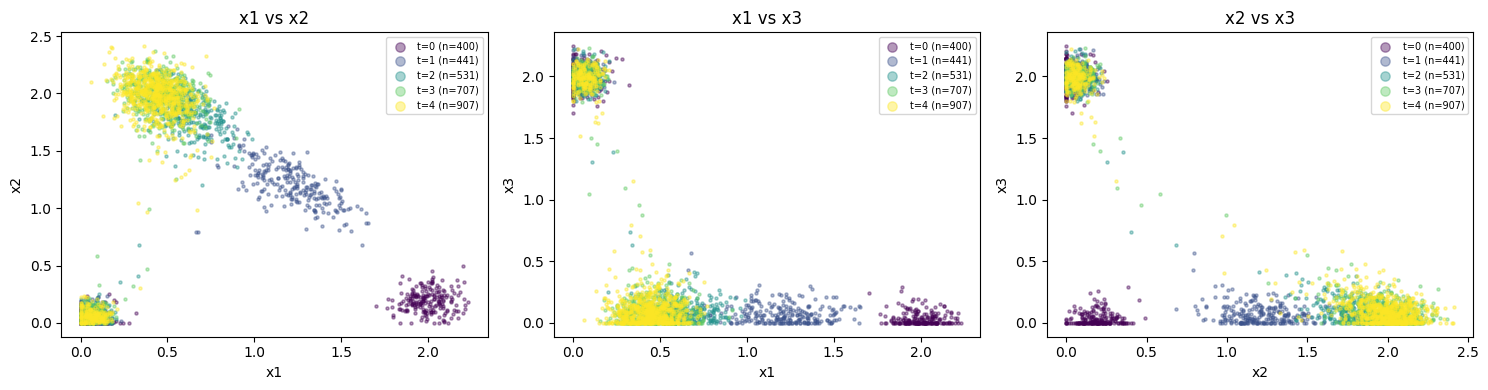

In [4]:
dim_pairs = [(0, 1), (0, 2), (1, 2)]
dim_names = ["x1", "x2", "x3"]
colors = plt.cm.viridis(np.linspace(0, 1, len(time_steps)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_idx, (d1, d2) in enumerate(dim_pairs):
    ax = axes[ax_idx]
    for i, t in enumerate(time_steps):
        pts = data_train[i].cpu().numpy()
        ax.scatter(pts[:, d1], pts[:, d2], c=[colors[i]], s=5, alpha=0.4,
                   label=f"t={t:.0f} (n={pts.shape[0]})")
    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f"{dim_names[d1]} vs {dim_names[d2]}")
    ax.legend(markerscale=3, fontsize=7)

plt.tight_layout()
plt.show()


In [5]:
config = {
    "sde": {
        "sigma": 0.05,
        "delta": 0.25 / (2 ** 0.5),  
        "dt": 0.05,
        "adjoint": False,
        "action_steps_per_segment": 10,
    },
    "model": {
        "velocity_type": "potential",
        "velocity_time_dependent": False,
        "activity_time_dependent": True,
        "alpha": 0.5,
        "r0": 1.0,
        "velocity": {
            "hidden_dim": 32,
            "n_hiddens": 4,
            "activation": "silu",
        },
        "activity": {
            "hidden_dim": 32,
            "n_hiddens": 3,
            "activation": "silu",
        },
        "weight_init": "xavier_uniform",
    },
    "optimizer": {
        "type": "rmsprop",
        "lr": 0.005,
        "weight_decay": 0.0,
    },
    "scheduler": {
        "type": "cosine",
        "T_max": None,
        "eta_min": 0.0001,
    },
    "train": {
        "niters": 500,
        "num_samples": 400,
        "gradient_clip": 1.0,
        "gradient_clip_type": "norm",
    },
    "sinkhorn": {
        "epsilon": 0.05,
        "epsilon_end": None,
        "n_iter": 500,
        "weight": 1.0,
        "use_growth_weight": True,
        "subsample": 1000,
    },
    "regularizers": {'action': 10},
    "output": {
        "verbose": True,
        "print_every": 50,
    },
}

print("Config:")
for section, values in config.items():
    print(f"  {section}: {values}")

Config:
  sde: {'sigma': 0.05, 'delta': 0.17677669529663687, 'dt': 0.05, 'adjoint': False, 'action_steps_per_segment': 10}
  model: {'velocity_type': 'potential', 'velocity_time_dependent': False, 'activity_time_dependent': True, 'alpha': 0.5, 'r0': 1.0, 'velocity': {'hidden_dim': 32, 'n_hiddens': 4, 'activation': 'silu'}, 'activity': {'hidden_dim': 32, 'n_hiddens': 3, 'activation': 'silu'}, 'weight_init': 'xavier_uniform'}
  optimizer: {'type': 'rmsprop', 'lr': 0.005, 'weight_decay': 0.0}
  scheduler: {'type': 'cosine', 'T_max': None, 'eta_min': 0.0001}
  train: {'niters': 500, 'num_samples': 400, 'gradient_clip': 1.0, 'gradient_clip_type': 'norm'}
  sinkhorn: {'epsilon': 0.05, 'epsilon_end': None, 'n_iter': 500, 'weight': 1.0, 'use_growth_weight': True, 'subsample': 1000}
  regularizers: {'action': 10}
  output: {'verbose': True, 'print_every': 50}


In [6]:
def create_model(n_dims, model_config, sde_config, device=None):
    """Create NeuralSDE model from config dicts."""
    vel = model_config.get("velocity", model_config.get("potential", {}))
    act = model_config.get("activity", {})

    func = NeuralSDE(
        in_out_dim=n_dims,
        sigma=sde_config["sigma"],
        delta=sde_config["delta"],
        alpha=model_config.get("alpha", 0.0),
        r0=model_config.get("r0", 1.0),
        velocity_type=model_config.get("velocity_type", "potential"),
        velocity_time_dependent=model_config.get("velocity_time_dependent", False),
        velocity_hidden_dim=vel.get("hidden_dim", 64),
        velocity_n_hiddens=vel.get("n_hiddens", 4),
        velocity_activation=vel.get("activation", "tanh"),
        activity_time_dependent=model_config.get("activity_time_dependent", False),
        activity_hidden_dim=act.get("hidden_dim", 64),
        activity_n_hiddens=act.get("n_hiddens", 3),
        activity_activation=act.get("activation", "tanh"),
    )

    if device is not None:
        func = func.to(device)

    weight_init = model_config.get("weight_init", "xavier_uniform")
    initialize_weights(func, method=weight_init)
    return func

print("create_model() defined.")

create_model() defined.


In [7]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

integral_time = time_steps

func = create_model(
    n_dims=n_dims,
    model_config=config["model"],
    sde_config=config["sde"],
    device=device,
)

n_params = sum(p.numel() for p in func.parameters())
print(f"Model parameters: {n_params}")
print(f"integral_time: {integral_time}")

train_result = train_loop(
    func=func,
    data_train=data_train,
    integral_time=integral_time,
    device=device,
    train_config=config["train"],
    sde_config=config["sde"],
    sinkhorn_config=config["sinkhorn"],
    optimizer_config=config["optimizer"],
    scheduler_config=config["scheduler"],
    reg_config=config["regularizers"],
    output_config=config["output"],
)

print(f"\nFinal loss: {train_result['final_loss']:.4f}")
print(f"Final sinkhorn mean: {train_result['final_sinkhorn_mean']:.4f}")

Model parameters: 5634
integral_time: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


  Training for 500 iterations...


/data1/okochi/miniconda3/envs/scdivide/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    Iter    1/500: loss=5.6217, Sink=[0.4624, 1.3087, 1.7955, 2.0405], action=0.0015 [3.2s]
    Iter   50/500: loss=0.1388, Sink=[0.0075, 0.0210, 0.0400, 0.0456], action=0.0025 [117.7s]
    Iter  100/500: loss=0.0590, Sink=[0.0037, 0.0121, 0.0111, 0.0073], action=0.0025 [240.5s]
    Iter  150/500: loss=0.0469, Sink=[0.0023, 0.0060, 0.0051, 0.0068], action=0.0027 [363.3s]
    Iter  200/500: loss=0.0429, Sink=[0.0025, 0.0058, 0.0045, 0.0042], action=0.0026 [482.4s]
    Iter  250/500: loss=0.0424, Sink=[0.0025, 0.0049, 0.0050, 0.0033], action=0.0027 [599.8s]
    Iter  300/500: loss=0.0405, Sink=[0.0020, 0.0044, 0.0033, 0.0041], action=0.0027 [720.8s]
    Iter  350/500: loss=0.0392, Sink=[0.0021, 0.0043, 0.0027, 0.0031], action=0.0027 [841.3s]
    Iter  400/500: loss=0.0386, Sink=[0.0017, 0.0042, 0.0030, 0.0028], action=0.0027 [959.2s]
    Iter  450/500: loss=0.0404, Sink=[0.0020, 0.0049, 0.0032, 0.0035], action=0.0027 [1079.4s]
    Iter  500/500: loss=0.0384, Sink=[0.0020, 0.0041, 0.0029,

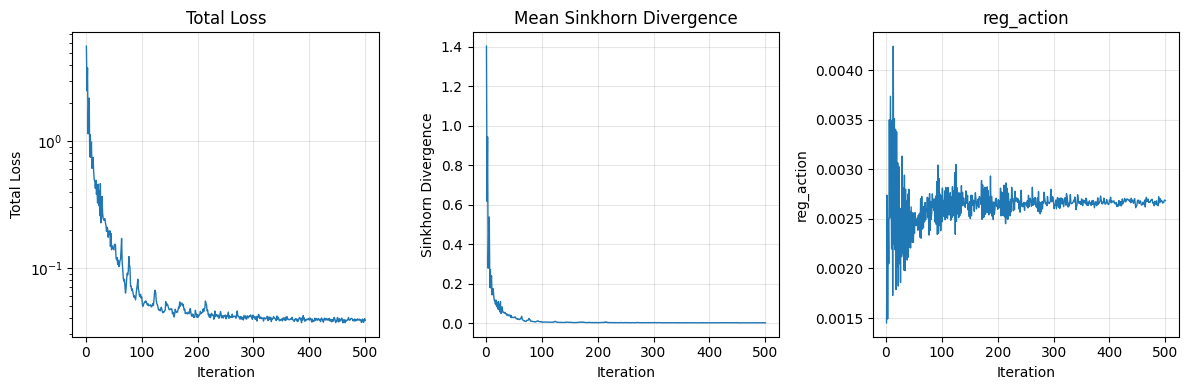

In [8]:
def plot_loss_history(loss_history):
    """Plot training loss history."""
    iters = [h["itr"] for h in loss_history]
    total_loss = [h["total_loss"] for h in loss_history]
    sinkhorn_mean = [h["sinkhorn_mean"] for h in loss_history]

    reg_keys = [k for k in loss_history[0] if k.startswith("reg_")]

    n_plots = 2 + len(reg_keys)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    ax = axes[0]
    ax.plot(iters, total_loss, linewidth=1.0)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Total Loss")
    ax.set_title("Total Loss")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(iters, sinkhorn_mean, linewidth=1.0)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Sinkhorn Divergence")
    ax.set_title("Mean Sinkhorn Divergence")
    ax.grid(True, alpha=0.3)

    for idx, rk in enumerate(reg_keys):
        ax = axes[2 + idx]
        vals = [h.get(rk, 0.0) for h in loss_history]
        ax.plot(iters, vals, linewidth=1.0)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(rk)
        ax.set_title(rk)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_loss_history(train_result["loss_history"])


In [9]:
def predict_from_t0(func, data_source, t_target, sde_config, device, n_samples=400):
    """Integrate from t=0 to t_target and return predicted positions + weights."""
    func.eval()
    with torch.no_grad():
        n_source = data_source.shape[0]
        if n_source >= n_samples:
            indices = torch.randperm(n_source)[:n_samples]
        else:
            indices = torch.randint(0, n_source, (n_samples,))
        x0 = data_source[indices].clone() + 0.02 * torch.randn(n_samples, data_source.shape[1]).to(device)
        lnw0 = torch.log(torch.ones(n_samples, 1) / n_samples).to(device)
        y0 = torch.cat([x0, lnw0], dim=1)

        ts = torch.tensor([0.0, t_target], device=device, dtype=torch.float32)
        ys = torchsde.sdeint(func, y0, ts, method='euler', dt=sde_config["dt"])

        y1 = ys[-1]
        z_pred = y1[:, :func.in_out_dim].cpu().numpy()
        lnw_pred = y1[:, func.in_out_dim:].cpu().numpy().squeeze()
        weights_pred = np.exp(np.clip(lnw_pred, -20, 20))
    func.train()
    return z_pred, weights_pred, lnw_pred

print("predict_from_t0() defined.")

predict_from_t0() defined.


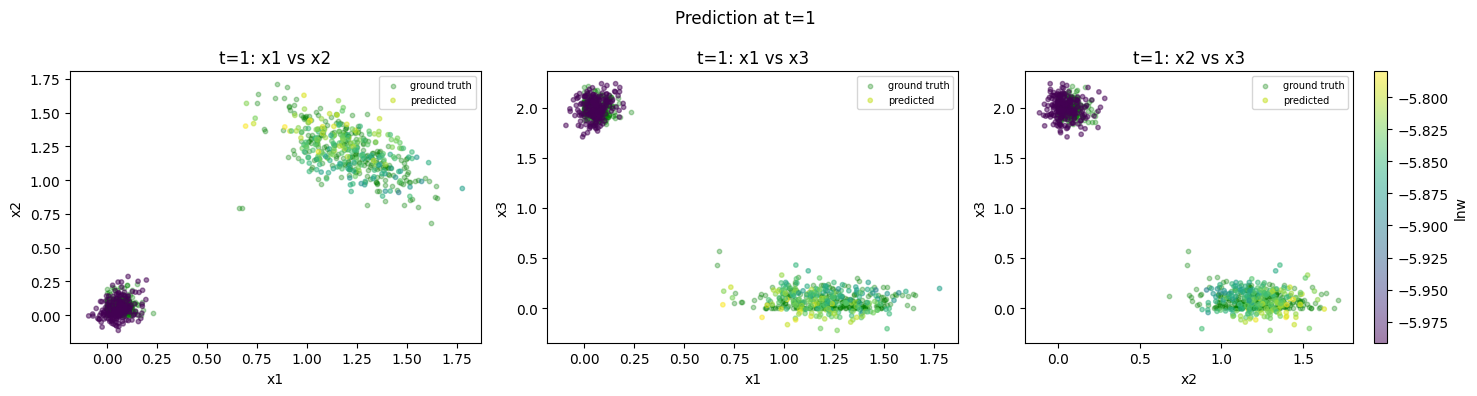

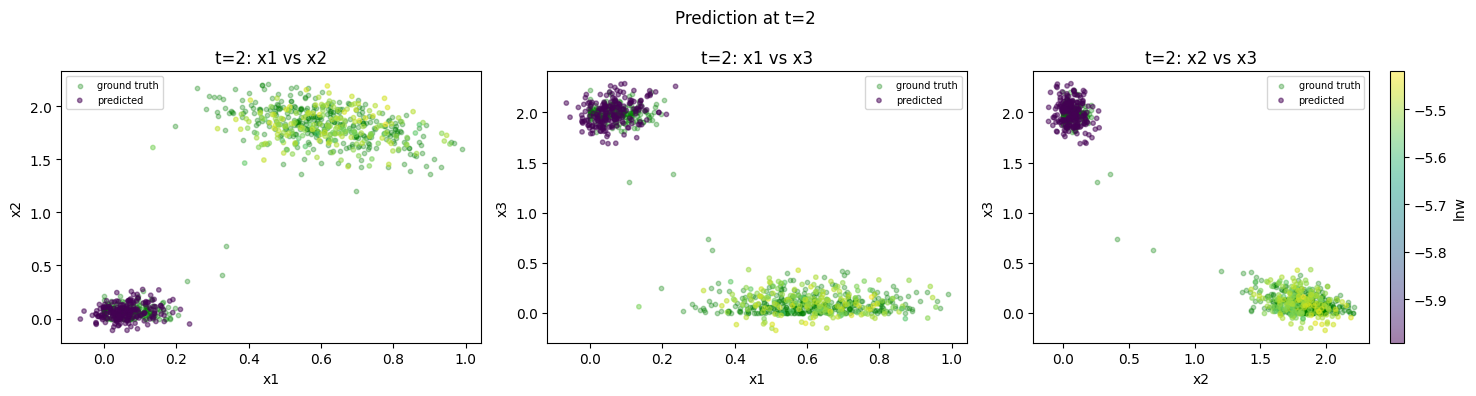

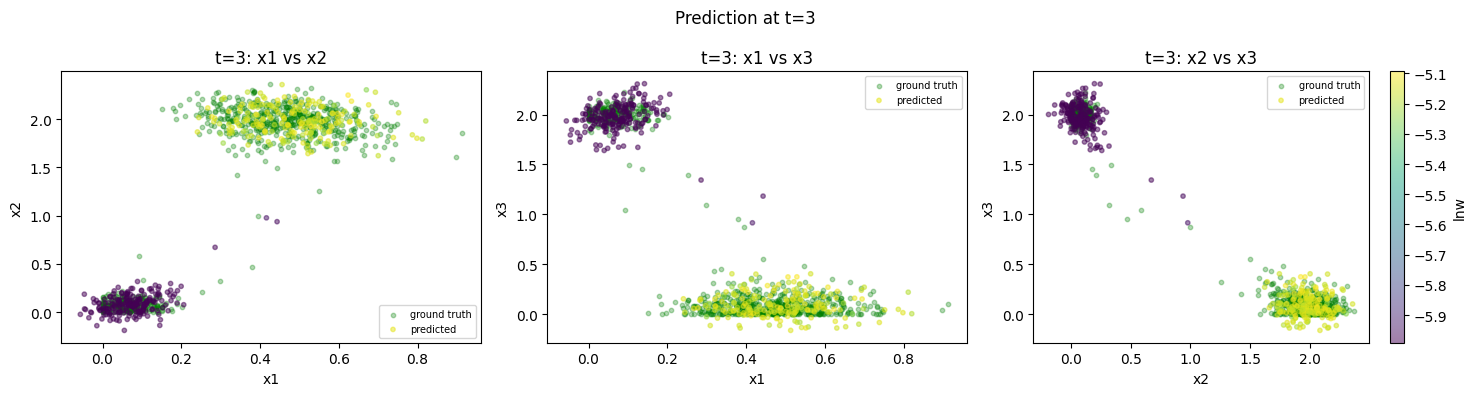

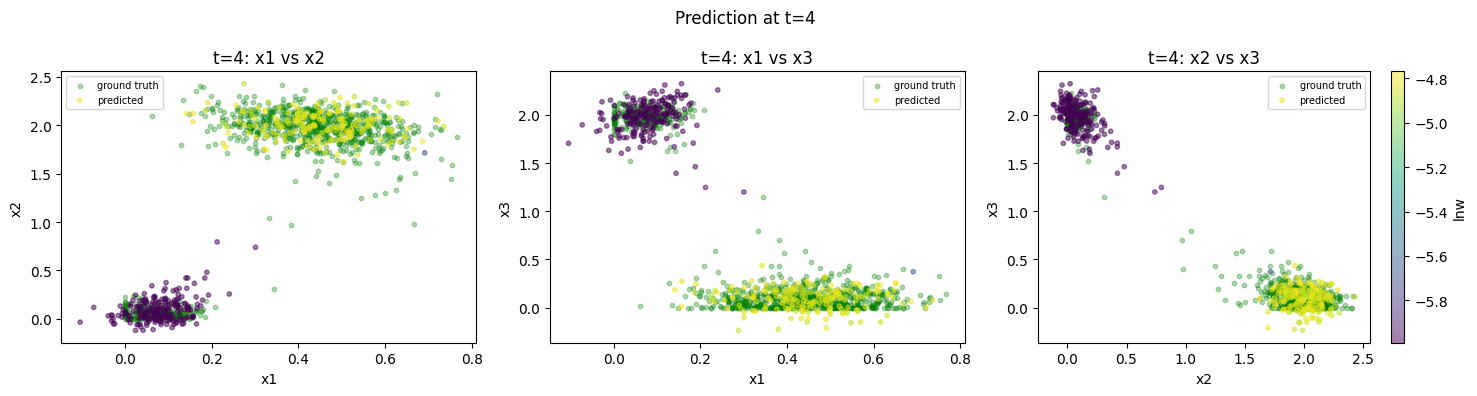

In [10]:
for t_target in time_steps[1:]:
    z_pred, weights_pred, lnw_pred = predict_from_t0(
        train_result["func"], data_train[0], t_target,
        config["sde"], device, n_samples=400,
    )
    z_gt = data_train[time_steps.index(t_target)].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax_idx, (d1, d2) in enumerate(dim_pairs):
        ax = axes[ax_idx]
        ax.scatter(z_gt[:, d1], z_gt[:, d2], c='green', alpha=0.3, s=10, label='ground truth')
        sc = ax.scatter(z_pred[:, d1], z_pred[:, d2], c=lnw_pred, cmap='viridis',
                        alpha=0.5, s=10, label='predicted')
        ax.set_xlabel(dim_names[d1])
        ax.set_ylabel(dim_names[d2])
        ax.set_title(f"t={t_target:.0f}: {dim_names[d1]} vs {dim_names[d2]}")
        ax.legend(fontsize=7)
    plt.colorbar(sc, ax=axes[-1], label='lnw')
    plt.suptitle(f"Prediction at t={t_target:.0f}")
    plt.tight_layout()
    plt.show()

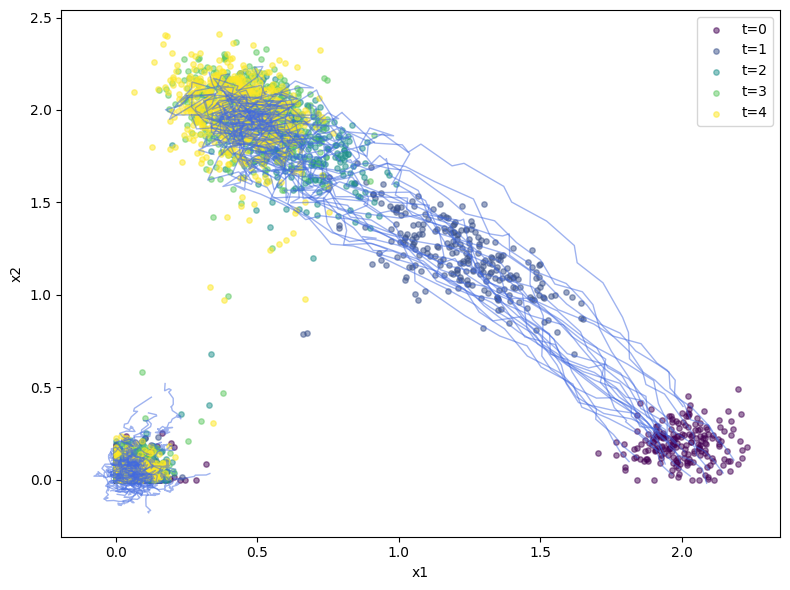

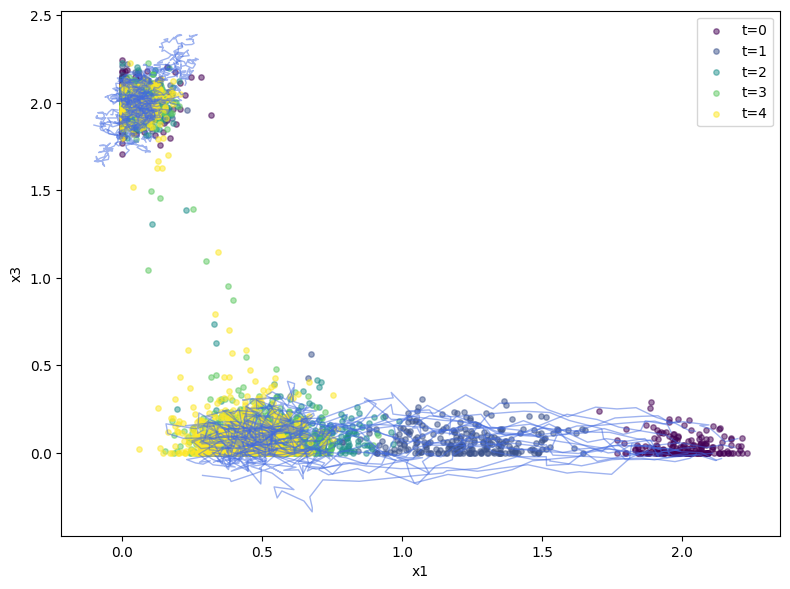

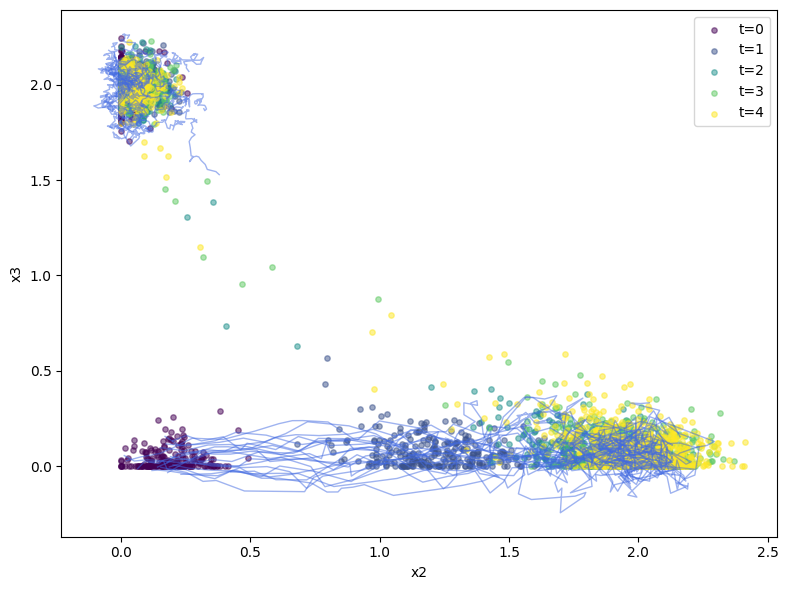

In [11]:
def plot_trajectory_sde(
    func, data_train, integral_time, sde_config, device,
    n_samples=30, dim1=0, dim2=1,
):
    """Plot trajectories using SDE simulation."""
    func.eval()

    init_data = data_train[0]
    if init_data.shape[0] > n_samples:
        idx = torch.randperm(init_data.shape[0])[:n_samples]
        x0 = init_data[idx].clone()
    else:
        x0 = init_data.clone()
        n_samples = x0.shape[0]

    x0 = x0 + 0.02 * torch.randn_like(x0)
    lnw0 = torch.log(torch.ones(n_samples, 1) / n_samples).to(device)
    y0 = torch.cat([x0, lnw0], dim=1)

    t_start = integral_time[0]
    t_end = integral_time[-1]
    n_steps = 50
    ts = torch.linspace(t_start, t_end, n_steps).to(device)

    with torch.no_grad():
        ys = torchsde.sdeint(func, y0, ts, method='euler', dt=sde_config["dt"])
        trajectories = ys[:, :, :func.in_out_dim].cpu().numpy()

    func.train()

    fig, ax = plt.subplots(figsize=(8, 6))

    for i in range(n_samples):
        ax.plot(
            trajectories[:, i, dim1],
            trajectories[:, i, dim2],
            'royalblue', alpha=0.5, linewidth=1.0
        )

    colors_t = plt.cm.viridis(np.linspace(0, 1, len(data_train)))
    for t_idx, d in enumerate(data_train):
        pts = d.cpu().numpy()
        ax.scatter(
            pts[:, dim1], pts[:, dim2],
            c=[colors_t[t_idx]], alpha=0.5, s=15, label=f"t={integral_time[t_idx]:.0f}"
        )

    dim_names_local = ["x1", "x2", "x3"]
    ax.set_xlabel(dim_names_local[dim1])
    ax.set_ylabel(dim_names_local[dim2])
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


for d1, d2 in dim_pairs:
    plot_trajectory_sde(
        func=train_result["func"],
        data_train=data_train,
        integral_time=time_steps,
        sde_config=config["sde"],
        device=device,
        n_samples=50,
        dim1=d1, dim2=d2,
    )


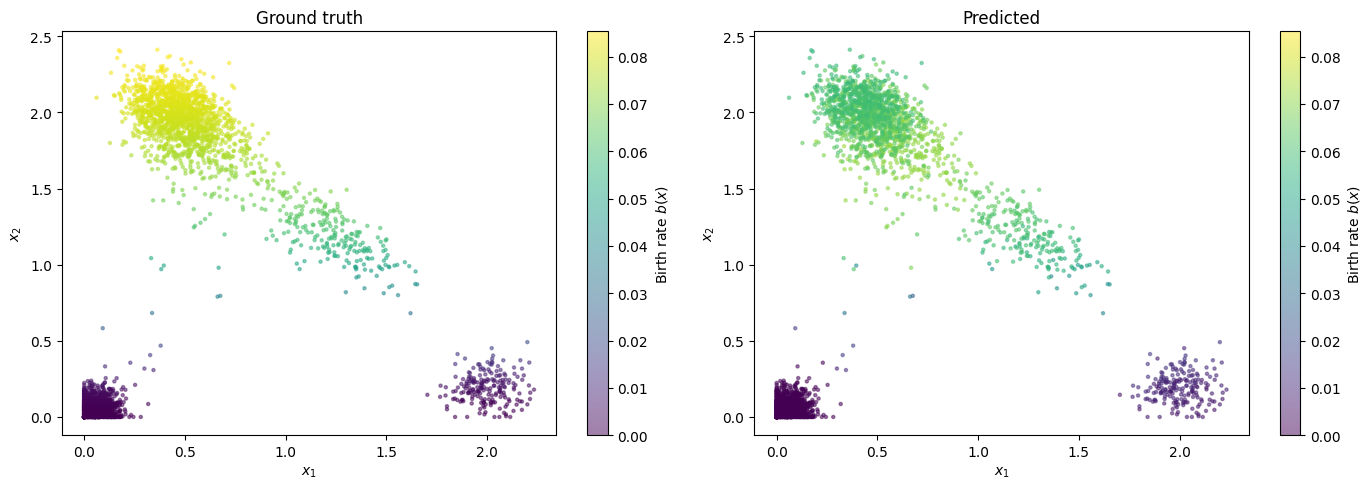

In [12]:
def ground_truth_birth_rate(x2, r_max=0.1):
    """b(x) = r_max * x2^2 / (1 + x2^2)"""
    return r_max * x2**2 / (1 + x2**2)


func = train_result["func"]
func.eval()

all_x1, all_x2, all_b_gt, all_b_pred = [], [], [], []
for i, t in enumerate(time_steps):
    z = data_train[i]
    x1_vals = z[:, 0].cpu().numpy()
    x2_vals = z[:, 1].cpu().numpy()
    all_x1.append(x1_vals)
    all_x2.append(x2_vals)
    all_b_gt.append(ground_truth_birth_rate(x2_vals))
    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    with torch.no_grad():
        all_b_pred.append(func.birth_rate(t_tensor, z).cpu().numpy().squeeze())

all_x1 = np.concatenate(all_x1)
all_x2 = np.concatenate(all_x2)
all_b_gt = np.concatenate(all_b_gt)
all_b_pred = np.concatenate(all_b_pred)

all_b_pred /= 10 #time scale

vmin = min(all_b_gt.min(), all_b_pred.min())
vmax = max(all_b_gt.max(), all_b_pred.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc1 = ax1.scatter(all_x1, all_x2, c=all_b_gt, cmap='viridis', s=5, alpha=0.5, vmin=vmin, vmax=vmax)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_title('Ground truth')
fig.colorbar(sc1, ax=ax1, label='Birth rate $b(x)$')

sc2 = ax2.scatter(all_x1, all_x2, c=all_b_pred, cmap='viridis', s=5, alpha=0.5, vmin=vmin, vmax=vmax)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Predicted')
fig.colorbar(sc2, ax=ax2, label='Birth rate $b(x)$')

plt.tight_layout()
plt.show()


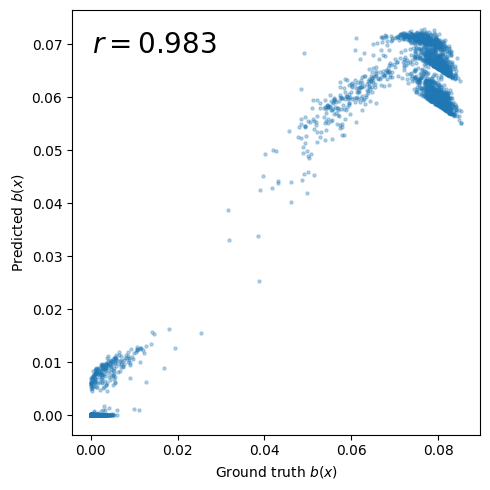

Pearson r = 0.9831, p = 0.00e+00


In [13]:
# Correlation: ground truth vs predicted birth rate
from scipy.stats import pearsonr

r, p = pearsonr(all_b_gt, all_b_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(all_b_gt, all_b_pred, s=5, alpha=0.3, c='tab:blue')

ax.set_xlabel('Ground truth $b(x)$')
ax.set_ylabel('Predicted $b(x)$')
ax.text(0.05, 0.95, f'$r = {r:.3f}$', transform=ax.transAxes,
        fontsize=20, verticalalignment='top')

plt.tight_layout()
plt.show()
print(f"Pearson r = {r:.4f}, p = {p:.2e}")

<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2629086/115188278.py:27: SyntaxWarning: invalid escape sequence '\p'
  fig.colorbar(sc, ax=ax, label="Potential $\phi(x)$")


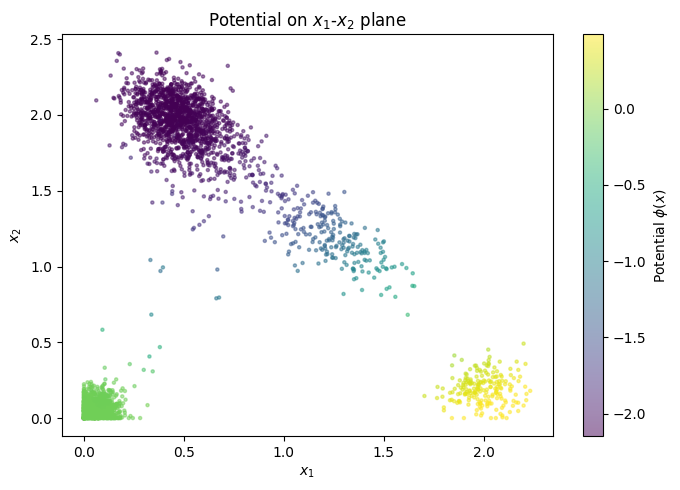

In [14]:
func = train_result["func"]
func.eval()

all_x1, all_x2, all_potential = [], [], []
for i, t in enumerate(time_steps):
    z = data_train[i]
    all_x1.append(z[:, 0].cpu().numpy())
    all_x2.append(z[:, 1].cpu().numpy())
    t_tensor = torch.tensor(t, dtype=torch.float32, device=device)
    with torch.no_grad():
        pot = func.potential(t_tensor, z).cpu().numpy().squeeze()
    all_potential.append(pot)

all_x1 = np.concatenate(all_x1)
all_x2 = np.concatenate(all_x2)
all_potential = np.concatenate(all_potential)

vmin = np.percentile(all_potential, 1)
vmax = np.percentile(all_potential, 99)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(all_x1, all_x2, c=all_potential, cmap="viridis", s=5, alpha=0.5,
                vmin=vmin, vmax=vmax)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Potential on $x_1$-$x_2$ plane")
fig.colorbar(sc, ax=ax, label="Potential $\phi(x)$")

plt.tight_layout()
plt.show()
